## 2D CSA

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
np.random.seed(42)

### Data Simulation
Binary Data (1 is match, 0 is a non match)
   - considering that $\mathbb{P}(0) = 1 - \mathbb{P}(1)$

In [3]:
def simulate_host_data(n, host_label):
    """
    Simulates scores for a specific host
        -  1: Match (the phage actually infects the host - low error)
        -  0: the phage does not infect the host - high error    
    """

    configs = {
        'Host A': {'mean': [0.1, 0.1], 'cov': [[0.005, 0], [0, 0.005]]},
        'Host B': {'mean': [0.15, 0.15], 'cov': [[0.03, 0], [0, 0.01]]}, # Oval
        'Host C': {'mean': [0.2, 0.2], 'cov': [[0.05, 0], [0, 0.05]]},  # Large/Weak
        'Host D': {'mean': [0.1, 0.4], 'cov': [[0.01, 0], [0, 0.01]]}   # Shifted
    }
    
    conf = configs.get(host_label, configs['Host A'])
    matching = np.abs(np.random.multivariate_normal(conf['mean'], conf['cov'], n))

    not_matching= np.abs(np.random.multivariate_normal([0.7, 0.7], [[0.02, 0], [0, 0.02]], n))

    return np.clip(matching, 0, 1), np.clip(not_matching, 0, 1)

### Construting the Envelope
we will get a single envelope per host

In [4]:
def get_host_envelope(training_matches, alpha, M):
    # Generating M directions for the convex shape
    angles = np.linspace(0, np.pi/2, M)
    u_directions = np.vstack([np.cos(angles), np.sin(angles)]).T
    
    # Projecting the true labels
    projections = training_matches @ u_directions.T

    # Finding the optimal beta
    beta_candidates = np.linspace(alpha/M, alpha, 500)
    beta_star = alpha/M
    q_tilde = np.quantile(projections, 1-beta_star, axis = 0)

    for beta in beta_candidates:
        q_beta = np.quantile(projections, 1-beta, axis = 0)
        inside = np.all(projections <= q_beta, axis = 1)
        coverage = np.mean(inside)
        if coverage >= 1-alpha:
            beta_star = beta
            q_tilde = q_beta
        else:
            break

    return u_directions, q_tilde

### Visualizing

In [5]:
def plot_binary_host_inference(host_name, matches, non_matches, u_dirs, q_tilde, s1, s0, alpha):
    plt.figure(figsize=(8, 7))
    
    # Plotting the calibration data
    plt.scatter(matches[:, 0], matches[:, 1], c='green', alpha=0.3, label="Known Matches (1)")
    plt.scatter(non_matches[:, 0], non_matches[:, 1], c='red', alpha=0.1, label="Known Non-Matches (0)")
    
    # Draw the 90% Envelope (The "Typical" Zone)
    x, y = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
    grid = np.vstack([x.ravel(), y.ravel()]).T
    inside = np.all((grid @ u_dirs.T) <= q_tilde, axis=1).reshape(x.shape)
    
    plt.contour(x, y, inside, levels=[0.5], colors='blue', linewidths=3)
    plt.contourf(x, y, inside, levels=[0.5, 1], colors='blue', alpha=0.05)

    # Inference logic
    in_envelope_s1 = np.all((s1 @ u_dirs.T) <= q_tilde)
    in_envelope_s0 = np.all((s0 @ u_dirs.T) <= q_tilde)

    # Plot Test Points
    plt.scatter(s1[0], s1[1], color='blue', marker='P', s=200, edgecolors='white', label="Test Score S1")
    plt.scatter(s0[0], s0[1], color='black', marker='X', s=200, edgecolors='white', label="Test Score S0")

    confidence_level  = (1-alpha)*100
    # Status labels
    status_s1 = f"IN (Host with {confidence_level}%) confidence" if in_envelope_s1 else "OUT"
    status_s0 = f"IN (Not a host {confidence_level}% confidence )" if in_envelope_s0 else "OUT"
    
    plt.title(f"Binary Inference for {host_name}\nS1 is {status_s1} | S0 is {status_s0}")
    plt.xlabel("Predictor 1 Score")
    plt.ylabel("Predictor 2 Score")
    plt.legend(loc='upper right')
    plt.grid(alpha=0.2)
    plt.show()

    return in_envelope_s1, in_envelope_s0

execution

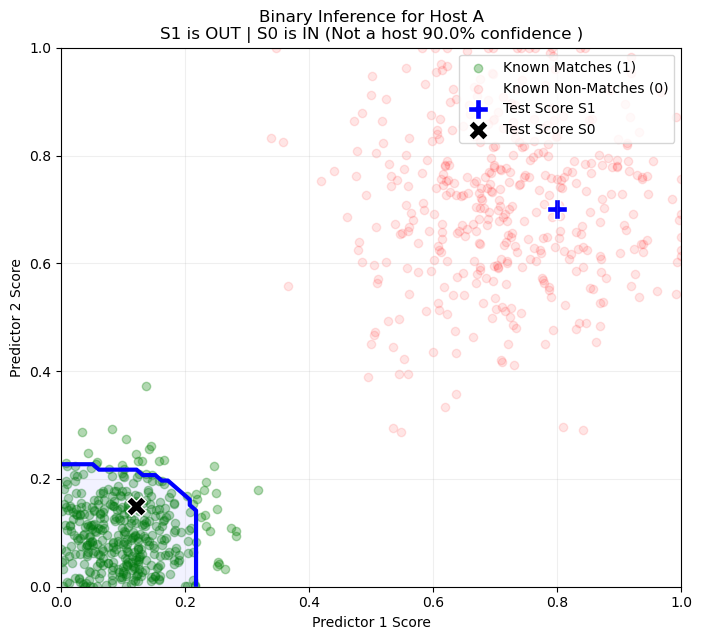

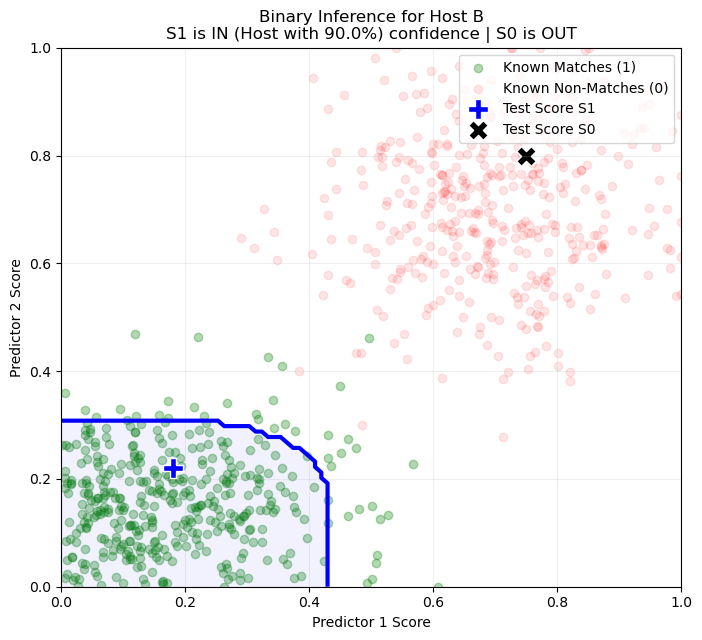

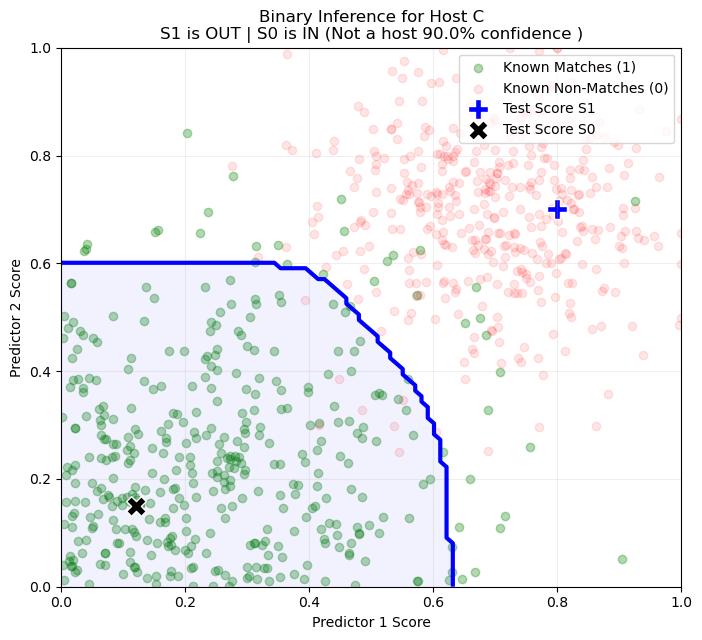

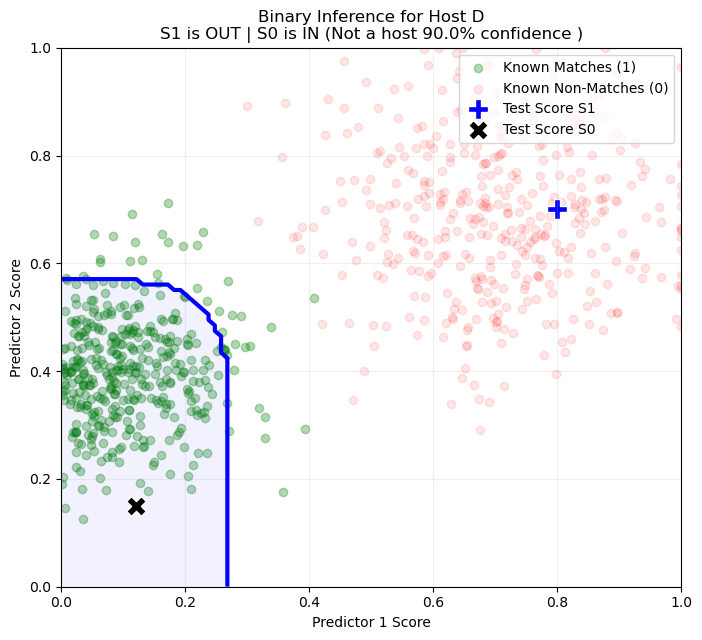


Final prediction set: ['Host B']


In [6]:
hosts = ['Host A', 'Host B', 'Host C', 'Host D']
alpha = 0.1
M = 100
final_prediction_set = []

# We will simulate a phage that actually infects host B
# so it should have a low S1 score for host B, but a high S1 score for other hosts

for host in hosts:
    # getting the calibration data for this host
    matches, not_matches = simulate_host_data(400, host)

    # getting the envelope    
    u_dirs, q_tilde = get_host_envelope(matches, alpha, M)

    # simulating the scores for the new phage for this specific host
    if host == 'Host B':
        s1_test = np.array([0.18, 0.22]) # Looks like a match
        s0_test = np.array([0.75, 0.80]) # Assumption of "No infection" looks like garbage
    else:
        s1_test = np.array([0.80, 0.70]) # Assumption of "Infection" looks like garbage
        s0_test = np.array([0.12, 0.15]) # Assumption of "No infection" looks typical (Low score)

    # Plotting
    is_match, is_not_match = plot_binary_host_inference(host, matches, not_matches, u_dirs, q_tilde, s1_test, s0_test, alpha)


    # If match is in the envelope and the not-match isnt --> we are very sure of the host
    # if not-match in the envelope and match isnt --> we are sure the host is not correct
    # If both in envelope, we keep the host to ensure coverage
    if is_match: final_prediction_set.append(host)

print(f"\nFinal prediction set: {final_prediction_set}")